In [ ]:
# South Africa Economic Indicators Analysis (2015–2024)
# Author: Modiehi Mphuthi
# Data Source: Stats SA & South African Reserve Bank (SARB)
# Description: Exploratory data analysis of key South African economic indicators including unemployment, inflation, GDP growth, and repo rate across 40 quarters from 2015 to 2024.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Libraries loaded successfully")


Libraries loaded successfully


In [5]:
# Load the dataset
df = pd.read_csv(r"C:\Users\ModiehiMphuthi\Downloads\sa_economic_indicators.csv")
# Preview the first few rows
df.head()

,Year,Quarter,Unemployment_Rate,Inflation_CPI,GDP_Growth,Repo_Rate
0,2015,Q1,26.4,4.0,2.1,5.75
1,2015,Q2,25.0,4.7,1.2,5.75
2,2015,Q3,25.5,4.6,0.7,6.00
3,2015,Q4,24.5,5.2,0.6,6.25
4,2016,Q1,26.7,6.3,-0.2,6.75


In [6]:
# Check the shape, data types and basic statistics
print("Shape:", df.shape)
print("\nColumn Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Shape: (40, 6)

Column Types:
 Year                   int64
Quarter               object
Unemployment_Rate    float64
Inflation_CPI        float64
GDP_Growth           float64
Repo_Rate            float64
dtype: object

Missing Values:
 Year                 0
Quarter              0
Unemployment_Rate    0
Inflation_CPI        0
GDP_Growth           0
Repo_Rate            0
dtype: int64

Basic Statistics:


,Year,Unemployment_Rate,Inflation_CPI,GDP_Growth,Repo_Rate
count,40.000000,40.000000,40.000000,40.000000,40.000000
mean,2019.500000,29.757500,4.972500,0.842500,6.237500
std,2.908872,3.327268,1.252892,3.645783,1.509532
min,2015.000000,23.300000,2.200000,-16.400000,3.500000
25%,2017.000000,27.100000,4.100000,0.275000,5.687500
50%,2019.500000,29.100000,4.900000,0.800000,6.625000
75%,2022.000000,32.750000,5.675000,1.750000,7.000000
max,2024.000000,35.300000,7.500000,13.600000,8.250000


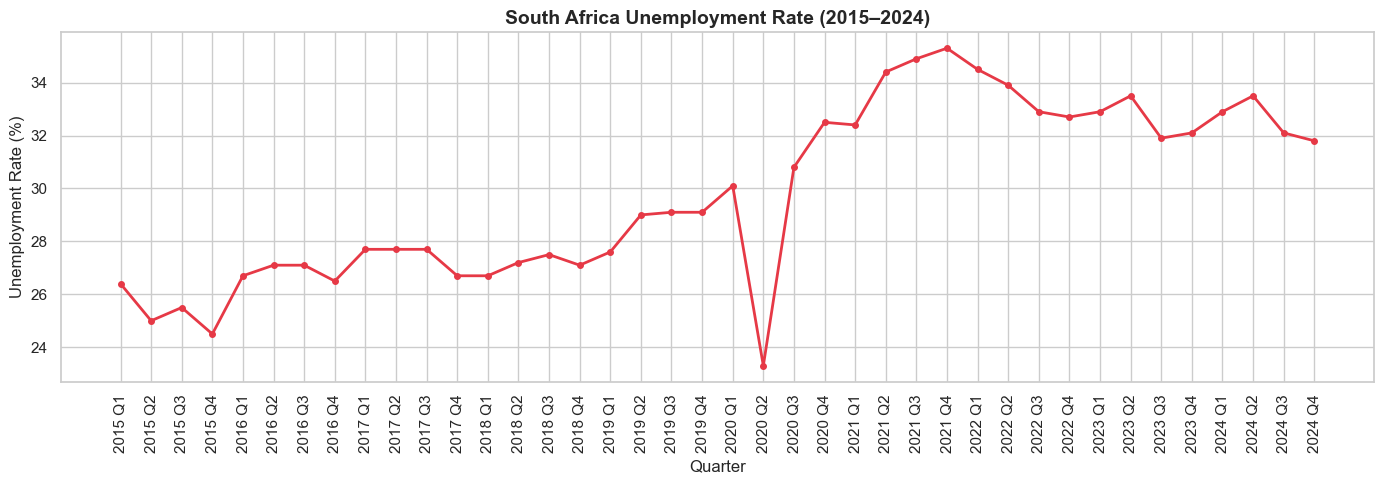

In [7]:
# Plot unemployment rate across all quarters
plt.figure(figsize=(14, 5))
plt.plot(df["Year"].astype(str) + " " + df["Quarter"], 
         df["Unemployment_Rate"], 
         color="#E63946", linewidth=2, marker="o", markersize=4)

plt.title("South Africa Unemployment Rate (2015–2024)", fontsize=14, fontweight="bold")
plt.xlabel("Quarter")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [15]:
# Key Insight: Unemployment Rate
print("""
INSIGHT — COVID-19 Anomaly (Q2 2020):
The unemployment rate appears to drop sharply in Q2 2020.
This is misleading — it reflects South Africa's narrow definition of unemployment.
During the hard lockdown, millions stopped actively seeking work and were therefore excluded from the unemployed count. The rate corrected sharply upward in Q3 2020
as people re-entered the labour market, and has remained above 30% since.
""")


INSIGHT — COVID-19 Anomaly (Q2 2020):
The unemployment rate appears to drop sharply in Q2 2020.
This is misleading — it reflects South Africa's narrow definition of unemployment.
During the hard lockdown, millions stopped actively seeking work and were therefore excluded from the unemployed count. The rate corrected sharply upward in Q3 2020
as people re-entered the labour market, and has remained above 30% since.



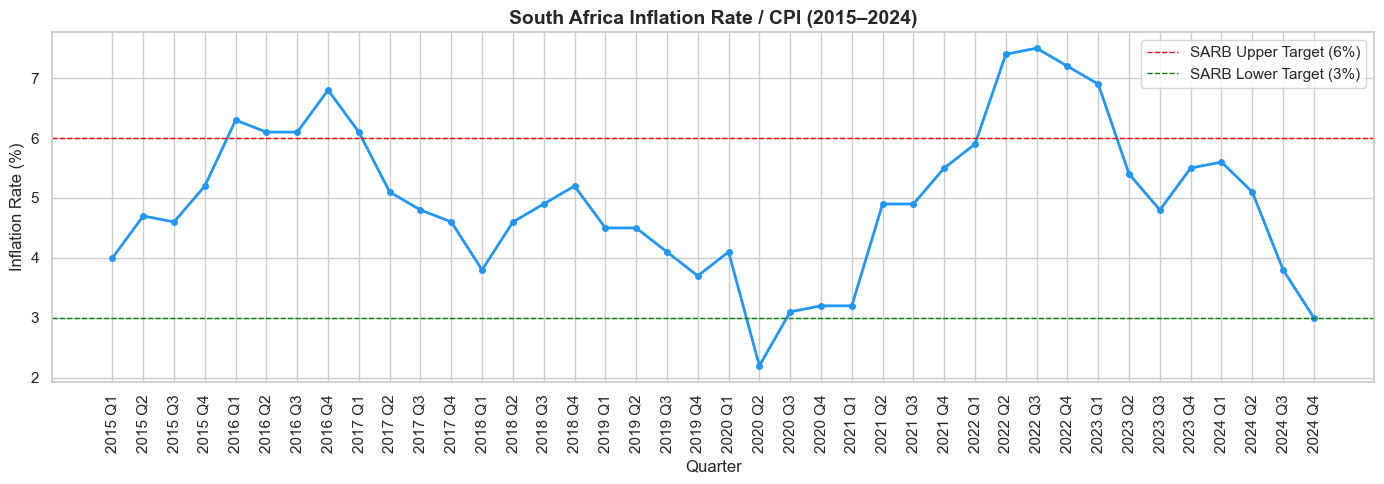

In [24]:
# Plot inflation rate across all quarters
plt.figure(figsize=(14, 5))
plt.plot(df["Year"].astype(str) + " " + df["Quarter"], #this is for concating the two columns (Year and Quarter to make it one) notice the space between them
         df["Inflation_CPI"], #column name used
         color="#2196F3", linewidth=2, marker="o", markersize=4)# doesn't really matter, just the colour you want, where the markersize is for the labels
#Also note that the plot function begins with x then y VIP!!
plt.axhline(y=6, color="red", linestyle="--", linewidth=1, label="SARB Upper Target (6%)") #Showing the targets
#Need to know the differences regarding the linestyle function, can be dashed, dotted, dashdot or just :
plt.axhline(y=3, color="green", linestyle="--", linewidth=1, label="SARB Lower Target (3%)") #Because we use real data, we put the two targets since that's what SARB
#looks into when they track the yearly rates

plt.title("South Africa Inflation Rate / CPI (2015–2024)", fontsize=14, fontweight="bold") # heading name
plt.xlabel("Quarter") #x-axis
plt.ylabel("Inflation Rate (%)") #y-axis
plt.xticks(rotation=90)
plt.legend() # this includes the legend
plt.tight_layout()
plt.show() # shows the table

In [26]:
# Key Insight: Inflation
print("""
INSIGHT — Inflation & SARB Target Band:
The SARB targets inflation between 3% and 6%. 
From 2015 to 2020, inflation remained largely within or close to the target band.
The post-COVID period (2021–2023) saw inflation breach the upper 6% threshold,
peaking in 2022 driven by global supply chain disruptions, rising fuel prices,
and food inflation. By late 2024 inflation returned within the target band.
""")


INSIGHT — Inflation & SARB Target Band:
The SARB targets inflation between 3% and 6%. 
From 2015 to 2020, inflation remained largely within or close to the target band.
The post-COVID period (2021–2023) saw inflation breach the upper 6% threshold,
peaking in 2022 driven by global supply chain disruptions, rising fuel prices,
and food inflation. By late 2024 inflation returned within the target band.



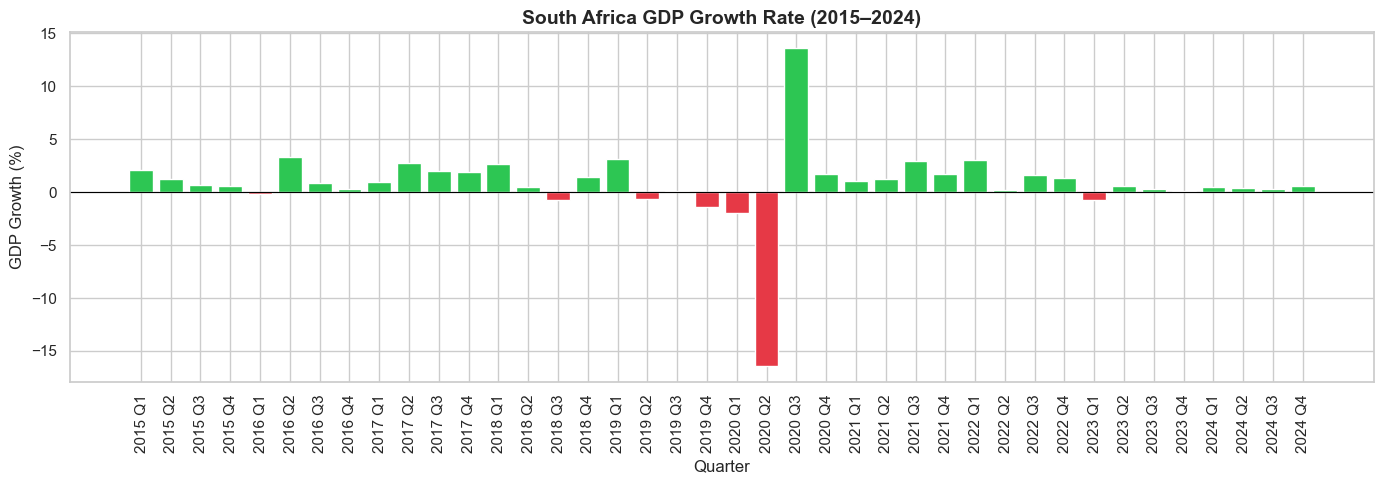

In [30]:
# Plot GDP growth across all quarters
plt.figure(figsize=(14, 5))
bars = plt.bar(df["Year"].astype(str) + " " + df["Quarter"],
               df["GDP_Growth"],
               color=["#E63946" if x < 0 else "#2DC653" for x in df["GDP_Growth"]])

plt.axhline(y=0, color="black", linewidth=0.8) #we include a separator to show where the growth was sitting at 0
plt.title("South Africa GDP Growth Rate (2015–2024)", fontsize=14, fontweight="bold")
plt.xlabel("Quarter")
plt.ylabel("GDP Growth (%)")
plt.xticks(rotation=90)#this is the angle used for the x labels, more like your rotation you check
plt.tight_layout()
plt.show() 

In [31]:
# Key Insight: GDP Growth
print("""
INSIGHT — GDP Growth & Recessions:
South Africa experienced two technical recessions in this period
(two consecutive quarters of negative GDP growth):
- 2018: Back-to-back contractions in Q3 and Q4
- 2020: The COVID-19 lockdown caused a historic -16.4% contraction in Q2 2020,
  the worst quarterly decline in post-apartheid history, followed by a sharp
  rebound in Q3 2020 as restrictions eased.
Growth has remained weak and inconsistent post-2020, reflecting structural
challenges including load shedding, logistics constraints, and low investment.
""")


INSIGHT — GDP Growth & Recessions:
South Africa experienced two technical recessions in this period
(two consecutive quarters of negative GDP growth):
- 2018: Back-to-back contractions in Q3 and Q4
- 2020: The COVID-19 lockdown caused a historic -16.4% contraction in Q2 2020,
  the worst quarterly decline in post-apartheid history, followed by a sharp
  rebound in Q3 2020 as restrictions eased.
Growth has remained weak and inconsistent post-2020, reflecting structural
challenges including load shedding, logistics constraints, and low investment.



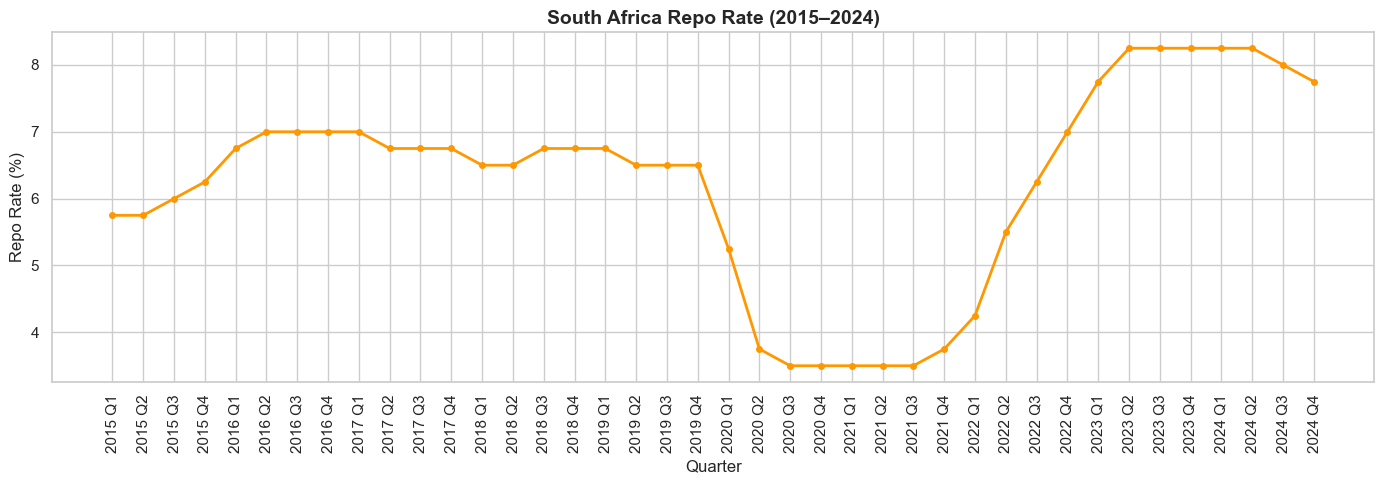

In [32]:
# Plot repo rate across all quarters
plt.figure(figsize=(14, 5))
plt.plot(df["Year"].astype(str) + " " + df["Quarter"],
         df["Repo_Rate"],
         color="#FF9800", linewidth=2, marker="o", markersize=4)#plt.plot is a line graph!

plt.title("South Africa Repo Rate (2015–2024)", fontsize=14, fontweight="bold")
plt.xlabel("Quarter")
plt.ylabel("Repo Rate (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [33]:
# Key Insight: Repo Rate
print("""
INSIGHT — Repo Rate & Monetary Policy:
The SARB uses the repo rate to manage inflation and stimulate or cool the economy.
Key movements in this period:
- 2015–2016: Gradual rate hikes to combat rising inflation
- 2020: Emergency cuts during COVID-19 brought the repo rate to a historic low of 3.50%
  to support the economy during lockdown
- 2021–2023: Aggressive hiking cycle as inflation surged post-COVID,
  reaching 8.25% by mid-2023 — the highest in over a decade
- Late 2024: First cuts begin as inflation returns to target band,
  signalling a shift back to accommodative monetary policy
""")


INSIGHT — Repo Rate & Monetary Policy:
The SARB uses the repo rate to manage inflation and stimulate or cool the economy.
Key movements in this period:
- 2015–2016: Gradual rate hikes to combat rising inflation
- 2020: Emergency cuts during COVID-19 brought the repo rate to a historic low of 3.50%
  to support the economy during lockdown
- 2021–2023: Aggressive hiking cycle as inflation surged post-COVID,
  reaching 8.25% by mid-2023 — the highest in over a decade
- Late 2024: First cuts begin as inflation returns to target band,
  signalling a shift back to accommodative monetary policy



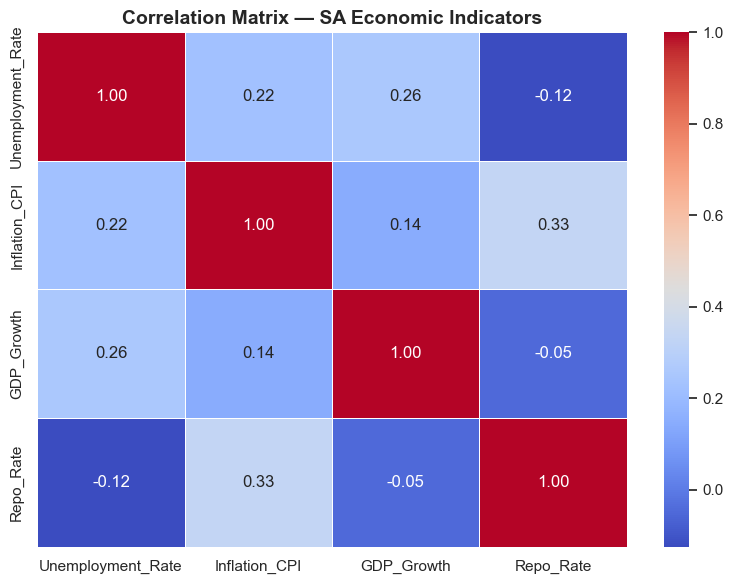

In [35]:
# Correlation between all indicators
plt.figure(figsize=(8, 6))
corr = df[["Unemployment_Rate", "Inflation_CPI", "GDP_Growth", "Repo_Rate"]].corr() #correlation for all the indicators showing how they relate to each other
#note that where an indicator intersects with itself it's '1' 

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix — SA Economic Indicators", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
#We use a heatmap visual to show how the indicators relate to each other, that is how does an increase of one indicator has an impact on the other one?
#Do they increase at the same rate? Are they related?
# 1 is positive relationship, 0 is no relationship and -1 is negative relationship (one goes up while the other goes down)
#We don't this all the time, but it's useful for showing insights and how maybe focusing on increasing one thing can have a positive impact on the other one

#The correlation matrix showed that no two indicators had a strong relationship in isolation, 
#which itself is an insight — it tells you SA's economy doesn't behave by the textbook, 
#and you need all four indicators together to tell the full story.

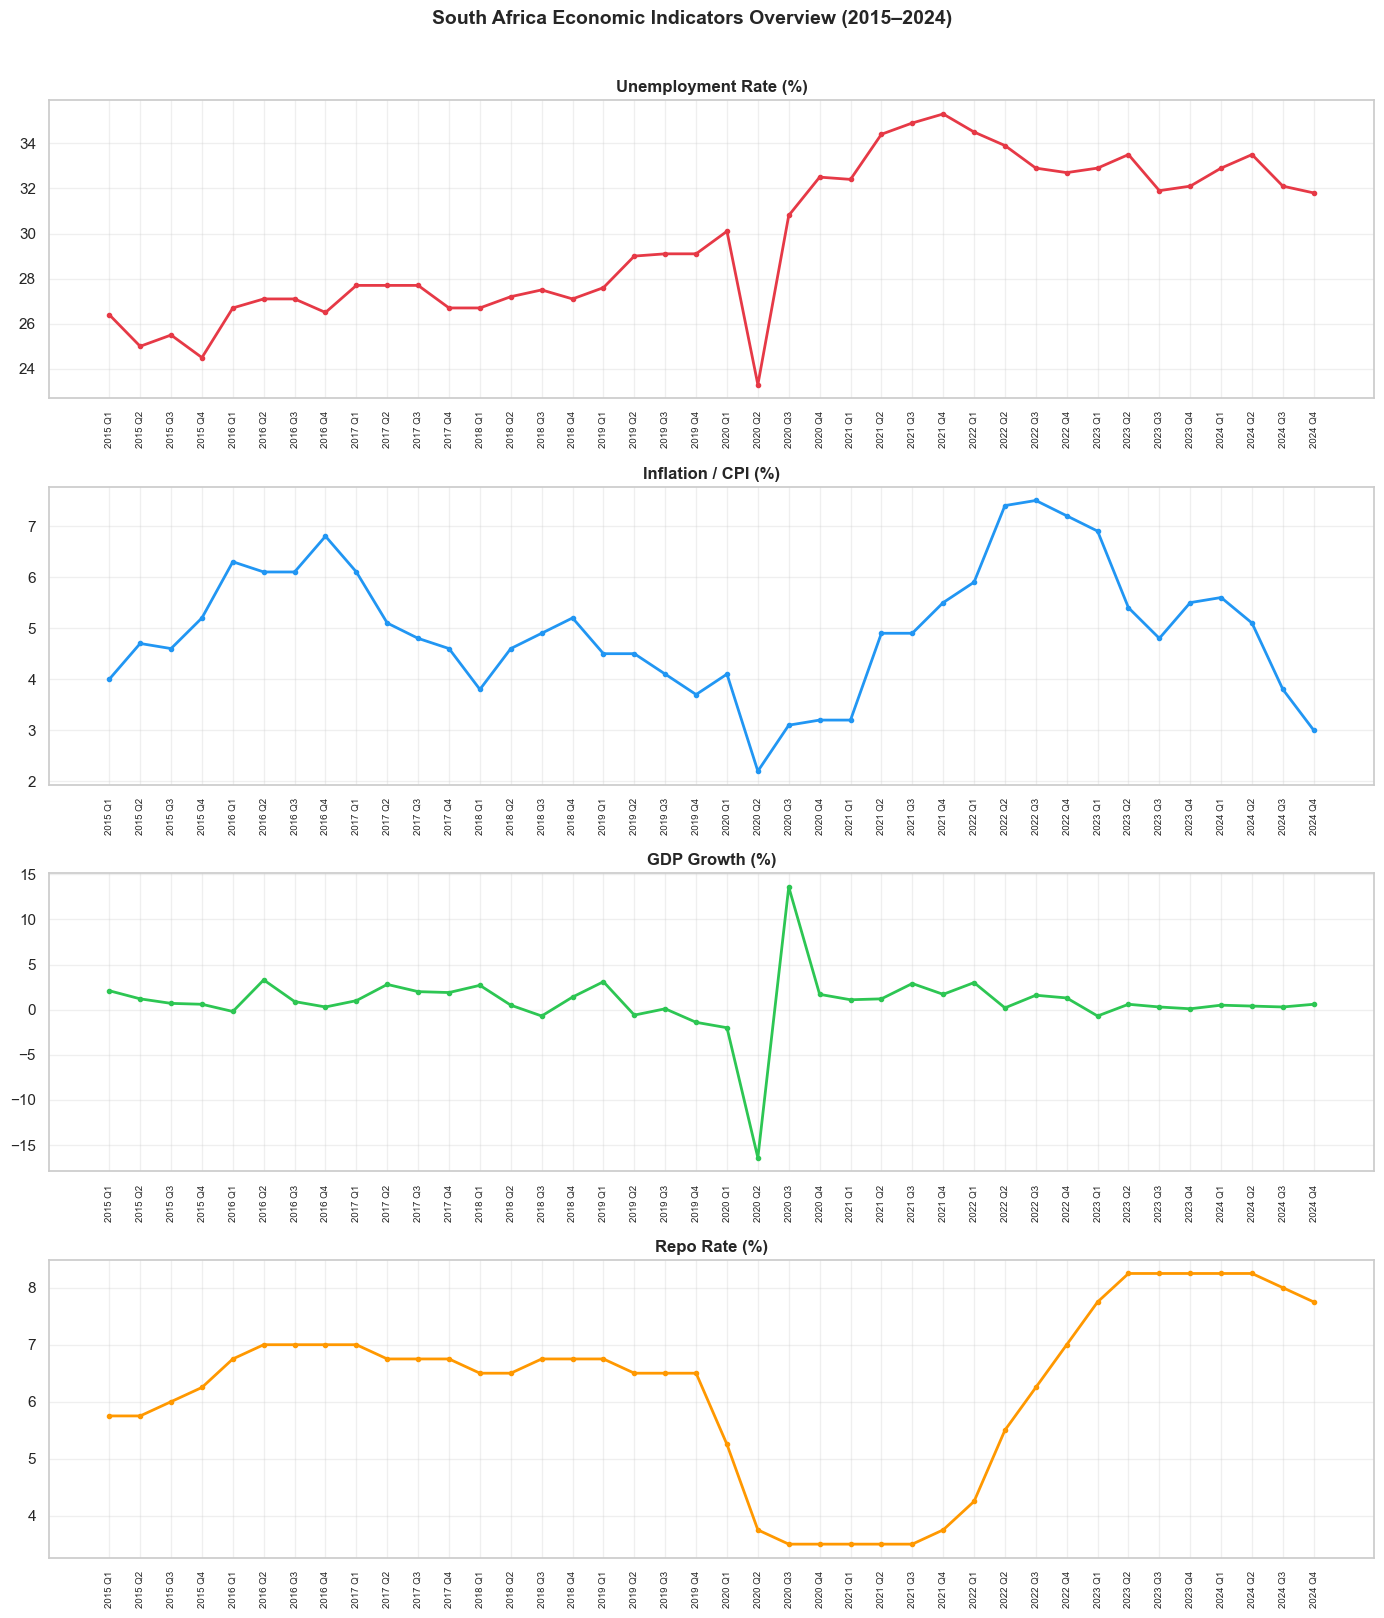

In [36]:
# Plot all four indicators together for comparison
fig, axes = plt.subplots(4, 1, figsize=(14, 16)) #having all the plots under one sheet

indicators = ["Unemployment_Rate", "Inflation_CPI", "GDP_Growth", "Repo_Rate"]
colors = ["#E63946", "#2196F3", "#2DC653", "#FF9800"]
titles = ["Unemployment Rate (%)", "Inflation / CPI (%)", "GDP Growth (%)", "Repo Rate (%)"]

x_labels = df["Year"].astype(str) + " " + df["Quarter"]

for i, (indicator, color, title) in enumerate(zip(indicators, colors, titles)):
    axes[i].plot(x_labels, df[indicator], color=color, linewidth=2, marker="o", markersize=3)
    axes[i].set_title(title, fontsize=12, fontweight="bold")
    axes[i].set_xticks(range(len(x_labels)))
    axes[i].set_xticklabels(x_labels, rotation=90, fontsize=7)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("South Africa Economic Indicators Overview (2015–2024)", 
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Final Summary of Analysis
print("""
================================================
SOUTH AFRICA ECONOMIC INDICATORS (2015–2024)
ANALYSIS SUMMARY
================================================

1. UNEMPLOYMENT
   - Remained persistently high throughout the period, never dropping below 23%
   - COVID-19 caused a misleading dip in Q2 2020 due to discouraged work-seekers
   - Peaked at 35.3% in Q4 2021 and has remained above 30% since

2. INFLATION
   - Largely within SARB's 3–6% target band from 2015–2020
   - Breached the upper target in 2022 due to post-COVID supply chain pressures
   - Returned within target by late 2024

3. GDP GROWTH
   - Weak and inconsistent throughout the period
   - Two recessions: 2018 and the historic COVID contraction of -16.4% in Q2 2020
   - Post-2020 recovery has been slow, reflecting structural economic challenges

4. REPO RATE
   - Cut aggressively during COVID to a historic low of 3.50%
   - Hiked sharply from 2021–2023 to combat inflation, reaching 8.25%
   - First cuts in late 2024 as inflation stabilised

KEY TAKEAWAY:
South Africa's economic indicators do not follow textbook patterns.
High unemployment persists regardless of growth cycles, inflation is
driven more by supply-side shocks than demand, and monetary policy
operates under significant structural constraints.
================================================
""")